# Compare smooth vs regular DRLB

This notebook compares two DRLB variants on the same train/validation split:

1. `regular hybrid`: `improved_hybrid_drlb_eval`
2. `smooth hybrid`: `improved_hybrid_drlb_smooth_eval`

It trains both variants, evaluates them on the validation split, saves metrics and diagnostics into `exp_tune_drlb_dqn_smooth/outputs`, and plots `dqn_loss` and `reward_net_loss` for both runs.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

notebook_dir = Path().resolve()
example_notebooks_dir = notebook_dir.parent.parent
bat_autobidding_dir = example_notebooks_dir.parent

if str(example_notebooks_dir) not in sys.path:
    sys.path.insert(0, str(example_notebooks_dir))
if str(bat_autobidding_dir) not in sys.path:
    sys.path.insert(0, str(bat_autobidding_dir))

from experiments.exp_configs import RND42N10Config, RND42TrainValHybridSmoothConfig
from simulator.model.drlb_bidder import DRLBBidder
from simulator.validation.check_results import autobidder_check

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)


/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
source_config = RND42N10Config()
config = RND42TrainValHybridSmoothConfig()
config.ensure_artifact_dirs()
config.config_dir.mkdir(parents=True, exist_ok=True)

VAL_FRACTION = 0.2
SPLIT_SEED = config.random_seed
OBJECTIVE = "clicks"
MAX_TRAIN_STEPS = None  # Set for a shorter smoke run if needed.
VERBOSE = False

COMMON_MODEL_PARAMS = {
    "dqn_gamma": 1.0,
    "dqn_lr": 1e-4,
    "dqn_target_update_interval": 100,
    "reward_net_lr": 1e-3,
}

COMMON_BASE_PARAMS = {
    "max_bid": 100.0,
    "T": 72,
    "lambda_min": 1e-6,
    "lambda_max": 10.0,
    "bids_per_timestep": 1,
}

SMOOTH_EXTRA_PARAMS = {
    "dqn_soft_update_tau": 0.01,
    "dqn_loss_type": "smooth_l1",
    "dqn_grad_clip_norm": 5.0,
    "dqn_reward_clip_value": 10.0,
}

RUN_SPECS = [
    {
        "label": "regular_hybrid",
        "exp_type": "improved_hybrid_drlb_eval",
        "extra_params": {},
    },
    {
        "label": "smooth_hybrid",
        "exp_type": "improved_hybrid_drlb_smooth_eval",
        "extra_params": SMOOTH_EXTRA_PARAMS,
    },
]

print("Config dir:", config.config_dir)
print("Outputs dir:", config.outputs_dir)


Config dir: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn_smooth/config
Outputs dir: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn_smooth/outputs


In [3]:
def ensure_train_val_split(source_config, target_config, val_fraction=0.2, seed=42):
    source_campaigns = pd.read_csv(source_config.data_config["train"]["campaigns_path"])
    source_stats = pd.read_csv(source_config.data_config["train"]["stats_path"])

    n_val = max(1, int(round(len(source_campaigns) * val_fraction)))
    val_campaigns = (
        source_campaigns
        .sample(n=n_val, random_state=seed)
        .sort_values("campaign_id")
        .reset_index(drop=True)
    )
    val_campaign_ids = set(val_campaigns["campaign_id"].astype(int).tolist())

    train_campaigns = (
        source_campaigns[~source_campaigns["campaign_id"].astype(int).isin(val_campaign_ids)]
        .sort_values("campaign_id")
        .reset_index(drop=True)
    )

    train_stats = source_stats[source_stats["campaign_id"].astype(int).isin(set(train_campaigns["campaign_id"].astype(int)))].copy()
    val_stats = source_stats[source_stats["campaign_id"].astype(int).isin(val_campaign_ids)].copy()

    train_campaigns.to_csv(target_config.data_config["train"]["campaigns_path"], index=False)
    train_stats.to_csv(target_config.data_config["train"]["stats_path"], index=False)
    val_campaigns.to_csv(target_config.data_config["test"]["campaigns_path"], index=False)
    val_stats.to_csv(target_config.data_config["test"]["stats_path"], index=False)

    metadata = {
        "source_experiment": source_config.experiment_name,
        "target_experiment": target_config.experiment_name,
        "seed": int(seed),
        "val_fraction": float(val_fraction),
        "train_campaigns": int(len(train_campaigns)),
        "val_campaigns": int(len(val_campaigns)),
        "train_stats_rows": int(len(train_stats)),
        "val_stats_rows": int(len(val_stats)),
    }
    metadata_path = target_config.config_dir / "train_val_split_metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2))
    return metadata


split_metadata = ensure_train_val_split(
    source_config=source_config,
    target_config=config,
    val_fraction=VAL_FRACTION,
    seed=SPLIT_SEED,
)

display(pd.DataFrame([split_metadata]))


,source_experiment,target_experiment,seed,val_fraction,train_campaigns,val_campaigns,train_stats_rows,val_stats_rows
0,exp_1_rnd_42_n10,exp_tune_drlb_dqn_smooth,42,0.2,1027,257,1246481,286690


In [4]:
train_stats_df = pd.read_csv(config.data_config["train"]["stats_path"])
val_stats_df = pd.read_csv(config.data_config["test"]["stats_path"])
train_campaigns_df = pd.read_csv(config.data_config["train"]["campaigns_path"])
val_campaigns_df = pd.read_csv(config.data_config["test"]["campaigns_path"])

display(pd.DataFrame([
    {
        "split": "train",
        "campaigns": int(train_campaigns_df["campaign_id"].nunique()),
        "stats_rows": int(len(train_stats_df)),
        "unique_periods": int(train_stats_df["period"].nunique()),
    },
    {
        "split": "val",
        "campaigns": int(val_campaigns_df["campaign_id"].nunique()),
        "stats_rows": int(len(val_stats_df)),
        "unique_periods": int(val_stats_df["period"].nunique()),
    },
]))


,split,campaigns,stats_rows,unique_periods
0,train,1027,1246481,351
1,val,257,286690,346


In [5]:
def score_to_dict(score, skipped_campaigns, time_inference_sec, time_overall_sec):
    return {
        "cpc_relative": float(score[0]),
        "rmse": float(score[1]),
        "clicks_sum": float(score[2]),
        "quickspend": float(score[3]),
        "skipped_campaigns": int(skipped_campaigns),
        "time_inference_sec": float(time_inference_sec),
        "time_overall_sec": float(time_overall_sec),
    }


def summarize_diagnostics(diagnostics_df):
    if diagnostics_df.empty:
        return {
            "train_steps": 0,
            "last_dqn_loss": None,
            "last_reward_net_loss": None,
            "dqn_loss_mean": None,
            "reward_net_loss_mean": None,
        }
    dqn_loss_nonzero = diagnostics_df.loc[diagnostics_df["dqn_loss"] > 0, "dqn_loss"]
    reward_net_nonzero = diagnostics_df.loc[diagnostics_df["reward_net_loss"] > 0, "reward_net_loss"]
    return {
        "train_steps": int(len(diagnostics_df)),
        "last_dqn_loss": float(diagnostics_df["dqn_loss"].iloc[-1]),
        "last_reward_net_loss": float(diagnostics_df["reward_net_loss"].iloc[-1]),
        "dqn_loss_mean": float(dqn_loss_nonzero.mean()) if not dqn_loss_nonzero.empty else None,
        "reward_net_loss_mean": float(reward_net_nonzero.mean()) if not reward_net_nonzero.empty else None,
    }


def build_bidder_params(spec, verbose=False):
    return {
        **COMMON_BASE_PARAMS,
        **COMMON_MODEL_PARAMS,
        **spec["extra_params"],
        "model_path": None,
        "exp_type": spec["exp_type"],
        "objective": OBJECTIVE,
        "eval_mode": True,
        "verbose": verbose,
        "use_tqdm": verbose,
        "debug_logs": False,
        "fit_log_every": 500,
        "inference_log_every": 24,
    }


def run_spec(spec, max_train_steps=None, verbose=False):
    bidder_params = build_bidder_params(spec, verbose=verbose)
    bidder = DRLBBidder(bidder_params)
    bidder.fit(
        train_stats_df,
        campaigns_df=train_campaigns_df,
        max_steps=max_train_steps,
        objective=OBJECTIVE,
    )

    diagnostics = bidder.get_training_diagnostics().copy()
    diagnostics_path = config.outputs_dir / f"{spec['label']}_training_diagnostics.csv"
    diagnostics.to_csv(diagnostics_path, index=False)

    model_path = config.best_models_dir / f"{spec['label']}.pt"
    bidder.save_model(str(model_path))

    eval_params = {
        **bidder_params,
        "input_campaigns": config.data_config["test"]["campaigns_path"],
        "input_stats": config.data_config["test"]["stats_path"],
        "model_path": str(model_path),
        "eval_mode": True,
    }
    result = autobidder_check(
        bidder=DRLBBidder,
        params=eval_params,
        auction_mode=config.auction_mode,
        verbose=verbose,
        log_every_campaigns=100,
        use_tqdm=verbose,
    )

    metrics = score_to_dict(
        score=result["score"],
        skipped_campaigns=result["skipped_campaigns"],
        time_inference_sec=result["time_inference_sec"],
        time_overall_sec=result["time_overall_sec"],
    )
    metrics.update({"label": spec["label"], "exp_type": spec["exp_type"]})
    metrics.update(summarize_diagnostics(diagnostics))

    metrics_path = config.outputs_dir / f"{spec['label']}_metrics.json"
    metrics_path.write_text(json.dumps(metrics, indent=2))

    diagnostics["label"] = spec["label"]
    return {
        "spec": spec,
        "metrics": metrics,
        "diagnostics": diagnostics,
        "model_path": model_path,
        "metrics_path": metrics_path,
        "diagnostics_path": diagnostics_path,
    }


## Run both variants

Run this cell to train and score both variants on the same split.


In [6]:
runs = [run_spec(spec, max_train_steps=MAX_TRAIN_STEPS, verbose=VERBOSE) for spec in RUN_SPECS]

comparison_df = pd.DataFrame([run["metrics"] for run in runs])
display(comparison_df[[
    "label",
    "exp_type",
    "clicks_sum",
    "cpc_relative",
    "rmse",
    "quickspend",
    "train_steps",
    "last_dqn_loss",
    "last_reward_net_loss",
    "dqn_loss_mean",
    "reward_net_loss_mean",
]])


,label,exp_type,clicks_sum,cpc_relative,rmse,quickspend,train_steps,last_dqn_loss,last_reward_net_loss,dqn_loss_mean,reward_net_loss_mean
0,regular_hybrid,improved_hybrid_drlb_eval,22.369190,9727.626471,1.236566,0.0,49200,92618.945312,10.753426,1.779769e+07,424867.800129
1,smooth_hybrid,improved_hybrid_drlb_smooth_eval,1126.985506,8910.553869,1.238199,0.0,49200,0.601820,74.465088,3.041526e+02,718652.644650


## Loss plots

These charts compare the raw diagnostic losses for both variants.


/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/amsafin/code/local_ml/rl/bat_venv/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(

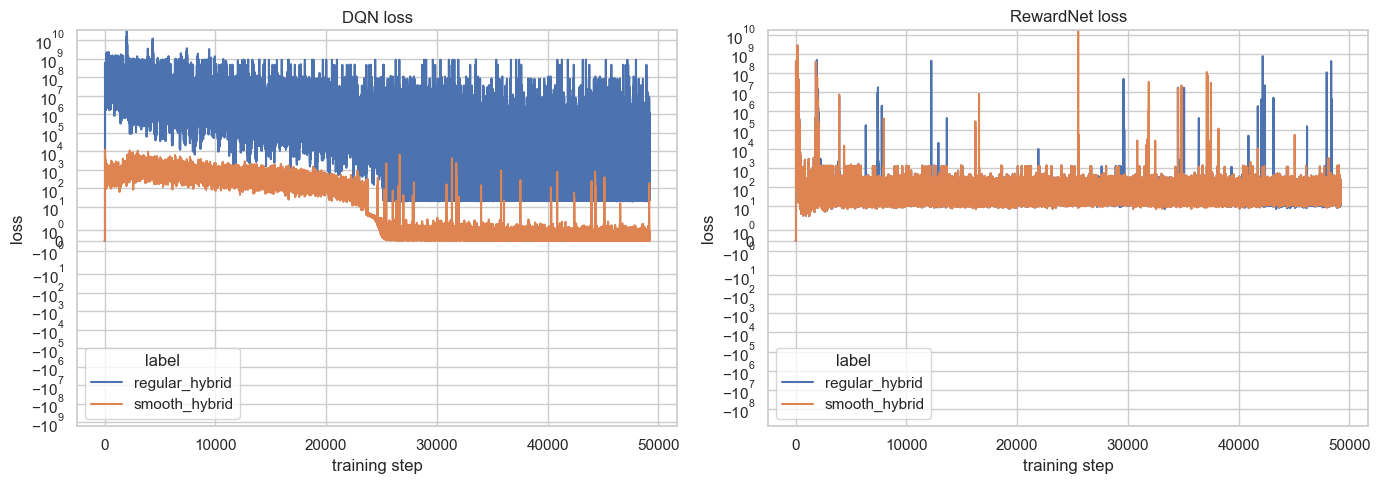

In [7]:
plot_df = pd.concat([run["diagnostics"] for run in runs], ignore_index=True)
plot_df["step"] = plot_df.groupby("label").cumcount() + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
sns.lineplot(data=plot_df, x="step", y="dqn_loss", hue="label", ax=axes[0])
axes[0].set_title("DQN loss")
axes[0].set_xlabel("training step")
axes[0].set_ylabel("loss")
axes[0].set_yscale("symlog")

sns.lineplot(data=plot_df, x="step", y="reward_net_loss", hue="label", ax=axes[1])
axes[1].set_title("RewardNet loss")
axes[1].set_xlabel("training step")
axes[1].set_ylabel("loss")
axes[1].set_yscale("symlog")

plt.tight_layout()
plt.show()


In [8]:
for run in runs:
    print(run["spec"]["label"])
    print("  model:", run["model_path"])
    print("  metrics:", run["metrics_path"])
    print("  diagnostics:", run["diagnostics_path"])


regular_hybrid
  model: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn_smooth/best_models/regular_hybrid.pt
  metrics: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn_smooth/outputs/regular_hybrid_metrics.json
  diagnostics: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn_smooth/outputs/regular_hybrid_training_diagnostics.csv
smooth_hybrid
  model: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn_smooth/best_models/smooth_hybrid.pt
  metrics: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn_smooth/outputs/smooth_hybrid_metrics.json
  diagnostics: /Users/amsafin/code/local_ml/rl/bat-autobidding-benchmark/example_notebooks/experiments/exp_tune_drlb_dqn_smooth/outputs/smooth_hybrid_training_diagnostics.cs